## Preprocessing Raw Data Untuk Aplikasi NexaBI
**NexaBI Adalah Next-Generation Business Intelligence Platform untuk Customer Analytics dan Product Recommendation pada Retail**

## Dataset Yang Digunakan
Data yang digunakan 

**Jumlah Data : 51291 Baris dengan 24 Kolom**

**Source = https://www.kaggle.com/datasets/apoorvaappz/global-super-store-dataset?select=Global_Superstore2.csv**

In [16]:
#Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')
print("Library Berhasil DiImport")

Library Berhasil DiImport


In [3]:
# Menampilkan Detail Dataset
df = pd.read_csv("Global_Superstore2.csv") 
df.info()
df.head()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
count,51290.00000,51290,51290,51290,51290,51290,51290,51290,51290,51290,...,51290,51290,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290
unique,NaN,25035,1430,1464,4,1590,795,3,3636,1094,...,10292,3,17,3788,NaN,NaN,NaN,NaN,NaN,4
top,NaN,CA-2014-100111,18-06-2014,22-11-2014,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,...,OFF-AR-10003651,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,14,135,130,30775,97,108,26518,915,2001,...,35,31273,6152,227,NaN,NaN,NaN,NaN,NaN,29433
mean,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,246.490581,3.476545,0.142908,28.610982,26.375915,NaN
std,14806.29199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,487.565361,2.278766,0.212280,174.340972,57.296804,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,0.000000,NaN
25%,12823.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,30.758625,2.000000,0.000000,0.000000,2.610000,NaN
50%,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,85.053000,3.000000,0.000000,9.240000,7.790000,NaN
75%,38467.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,251.053200,5.000000,0.200000,36.810000,24.450000,NaN


<function matplotlib.pyplot.show(close=None, block=None)>

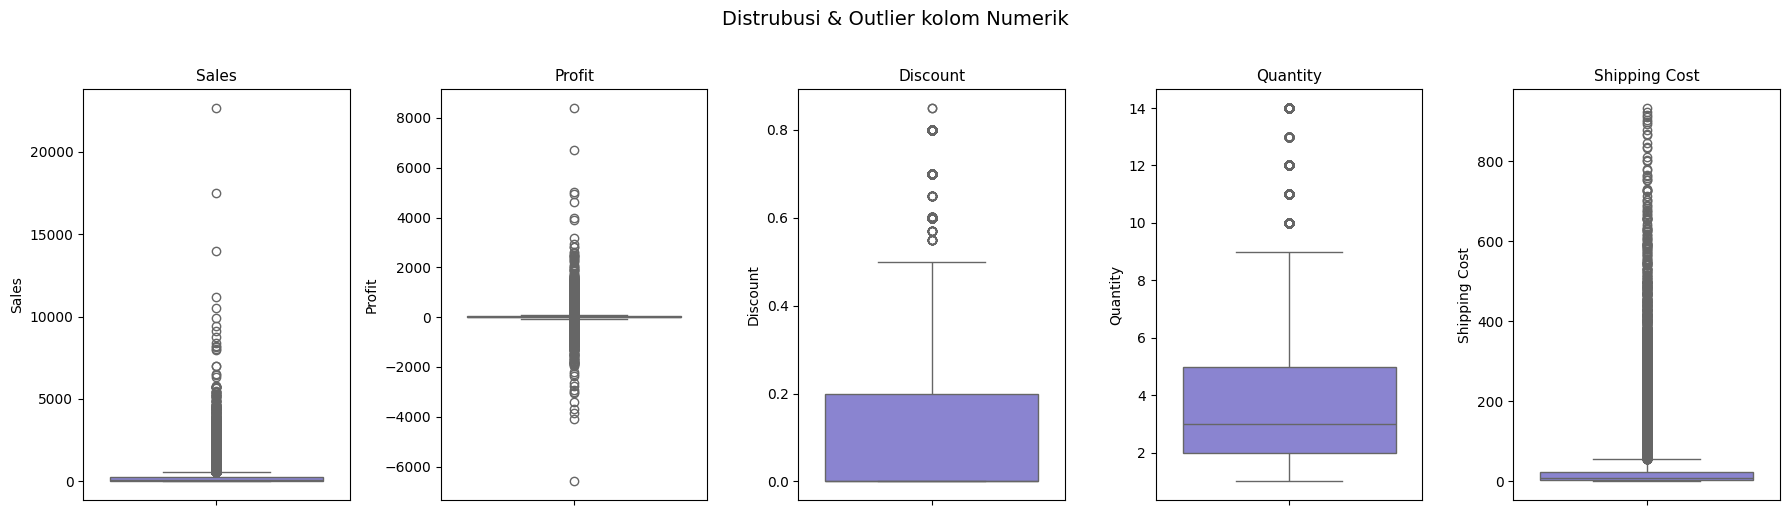

In [4]:
# Visualisasi Raw Data
# Visualisasi Boxplot pada Kolom : Sales,profit,discount,quantity,dan shipping cost

num_cols = ['Sales','Profit','Discount','Quantity','Shipping Cost']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#7F77DD')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
plt.suptitle('Distrubusi & Outlier kolom Numerik', fontsize = 14, y=1.02)
plt.tight_layout()
plt.show

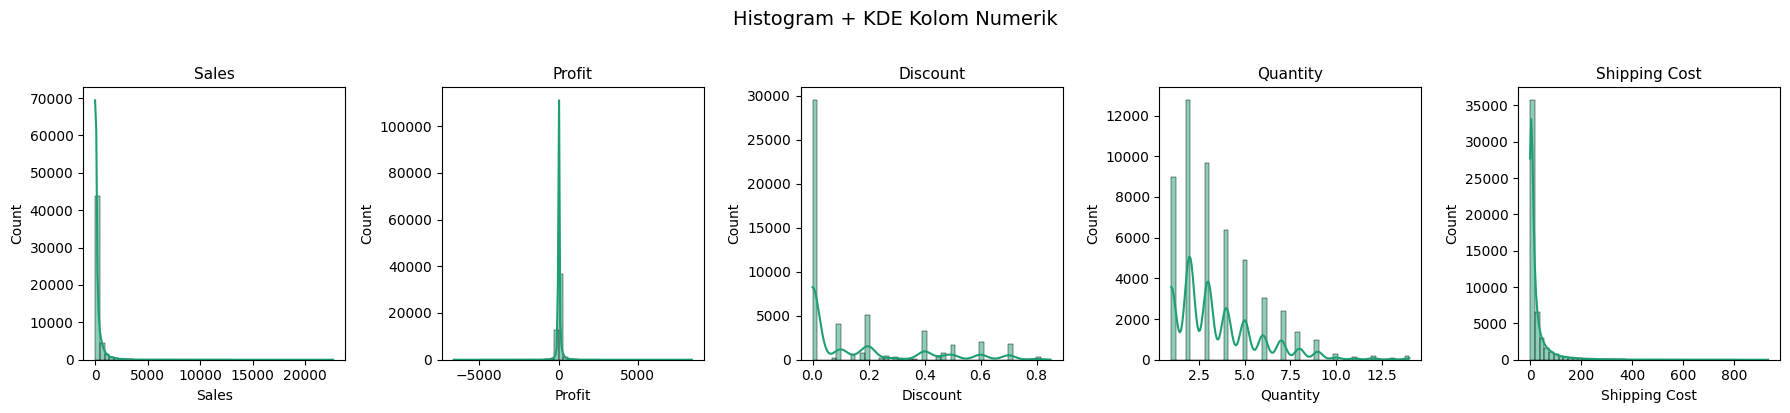

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i], color='#1D9E75')
    axes[i].set_title(col, fontsize=11)
plt.suptitle('Histogram + KDE Kolom Numerik', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

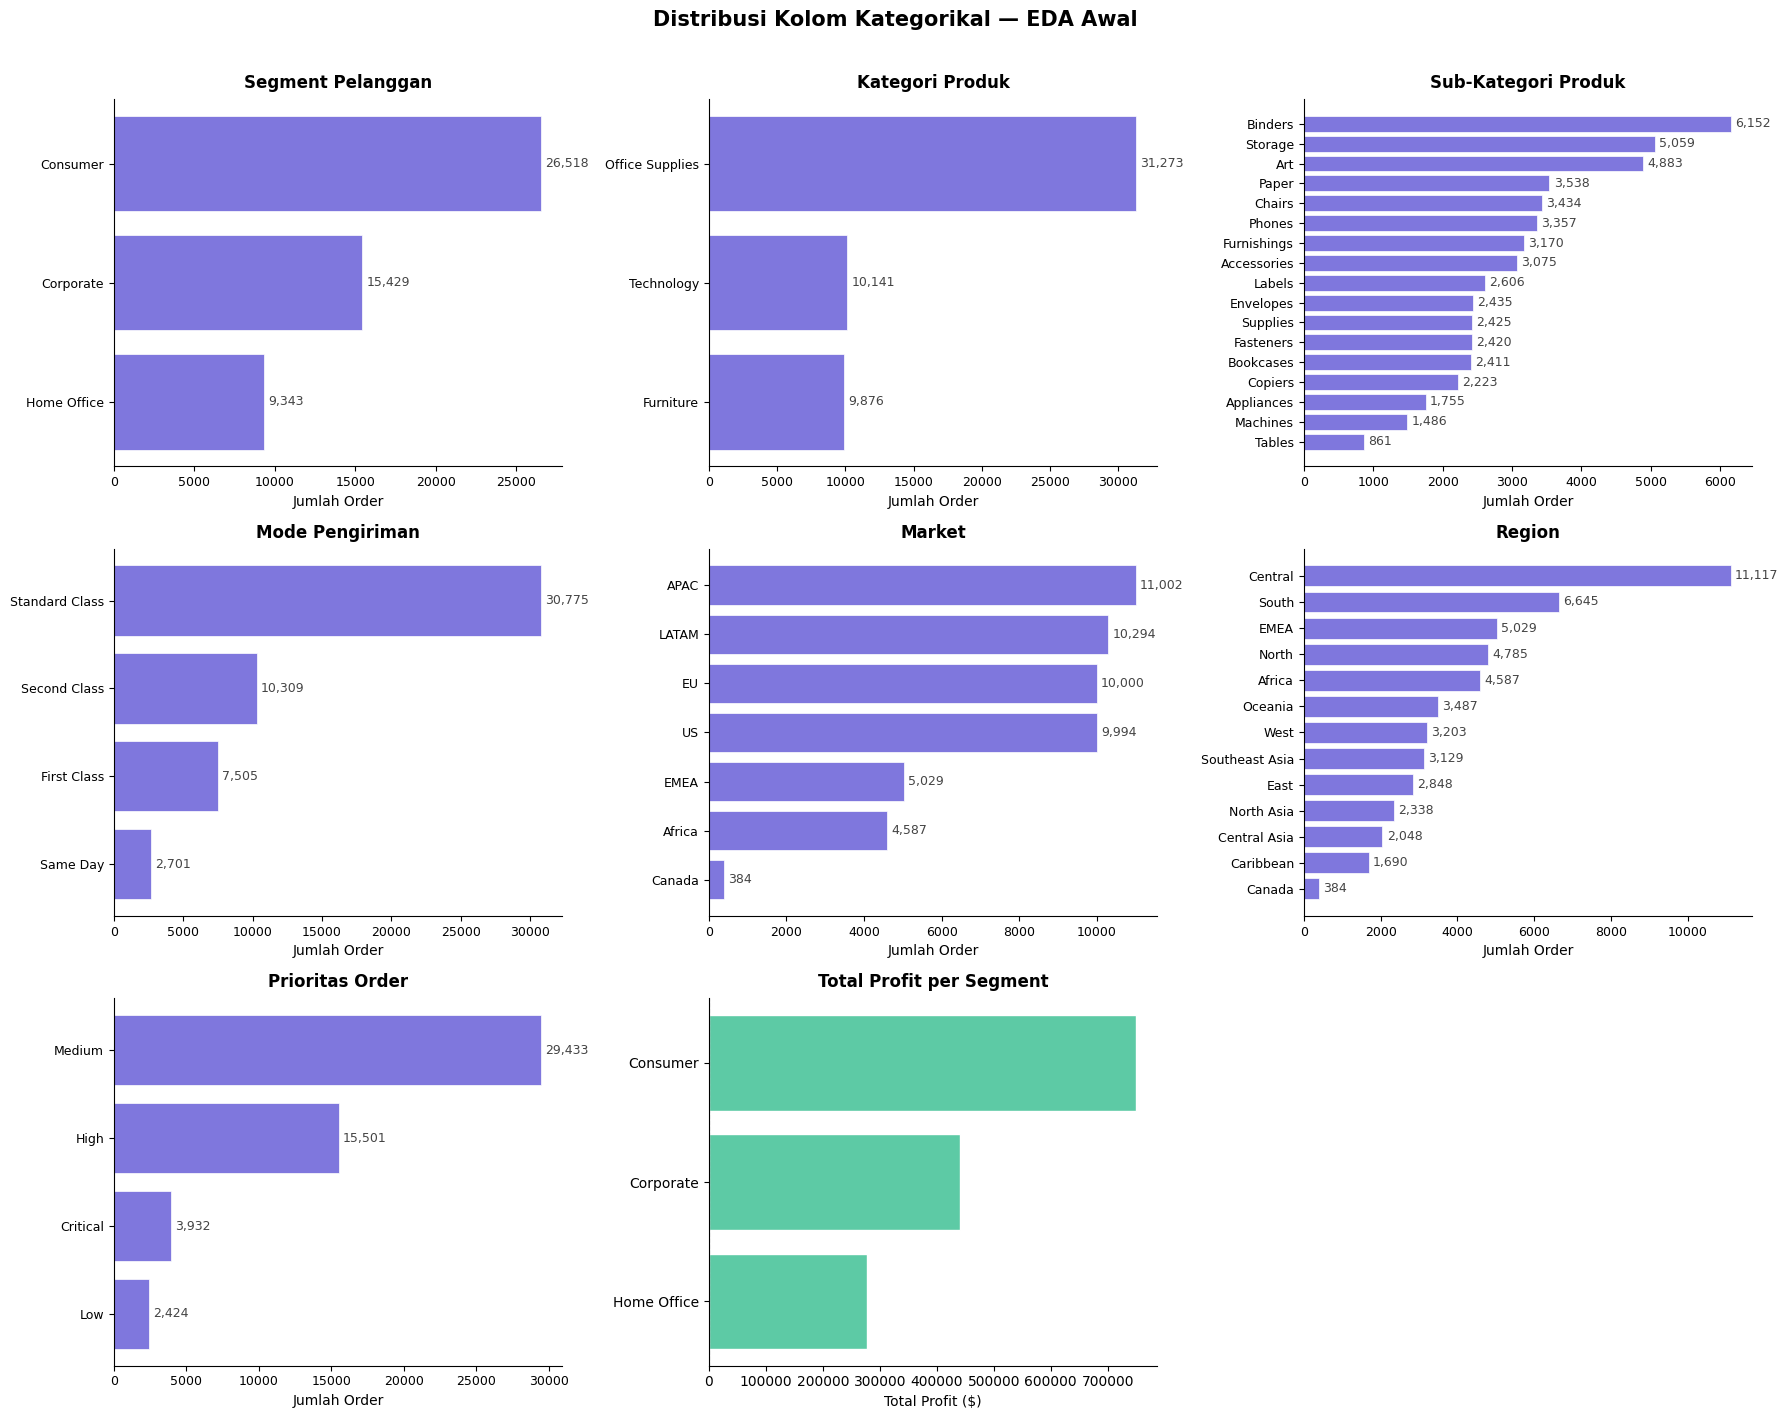

Visualisasi bar chart kategorikal berhasil disimpan


In [8]:
cat_cols = {
    'Segment':        'Segment Pelanggan',
    'Category':       'Kategori Produk',
    'Sub-Category':   'Sub-Kategori Produk',
    'Ship Mode':      'Mode Pengiriman',
    'Market':         'Market',
    'Region':         'Region',
    'Order Priority': 'Prioritas Order',
}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (col, title) in enumerate(cat_cols.items()):
    counts = df[col].value_counts().sort_values(ascending=True)
    bars = axes[i].barh(counts.index, counts.values, color='#7F77DD', edgecolor='white', linewidth=0.5)
    axes[i].set_title(title, fontsize=12, fontweight='bold', pad=8)
    axes[i].set_xlabel('Jumlah Order', fontsize=10)
    # Tambah angka di ujung bar
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_width() + counts.values.max() * 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=9, color='#444')
    axes[i].spines[['top','right']].set_visible(False)
    axes[i].tick_params(labelsize=9)

# Menyembunyikan subplot kosong
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

# ]subplot khusus: Profit per Segment (insight untuk clustering)
ax_extra = axes[len(cat_cols)]
ax_extra.set_visible(True)
profit_seg = df.groupby('Segment')['Profit'].sum().sort_values(ascending=True)
colors = ['#F0997B' if v < 0 else '#5DCAA5' for v in profit_seg.values]
bars = ax_extra.barh(profit_seg.index, profit_seg.values, color=colors, edgecolor='white')
ax_extra.set_title('Total Profit per Segment', fontsize=12, fontweight='bold', pad=8)
ax_extra.set_xlabel('Total Profit ($)', fontsize=10)
ax_extra.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax_extra.spines[['top','right']].set_visible(False)

plt.suptitle('Distribusi Kolom Kategorikal — EDA Awal', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz1_bar_kategorikal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi bar chart kategorikal berhasil disimpan")

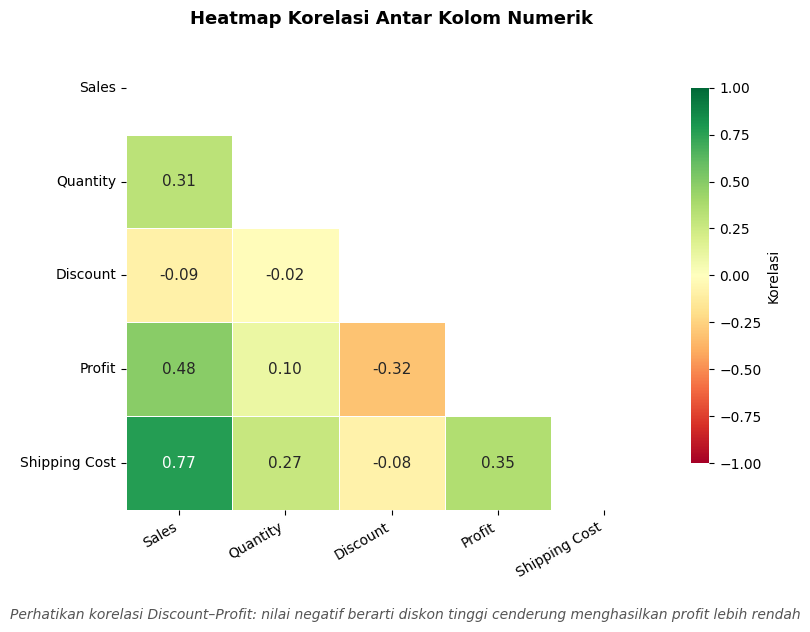

heatmap korelasi berhasil disimpan


In [9]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']

fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols].corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # sembunyikan segitiga atas (duplikat)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 11},
    cbar_kws={'shrink': 0.8, 'label': 'Korelasi'}
)
ax.set_title('Heatmap Korelasi Antar Kolom Numerik', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# Anotasi insight
fig.text(0.5, -0.04,
         'Perhatikan korelasi Discount–Profit: nilai negatif berarti diskon tinggi cenderung menghasilkan profit lebih rendah',
         ha='center', fontsize=10, color='#555', style='italic')

plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("heatmap korelasi berhasil disimpan")

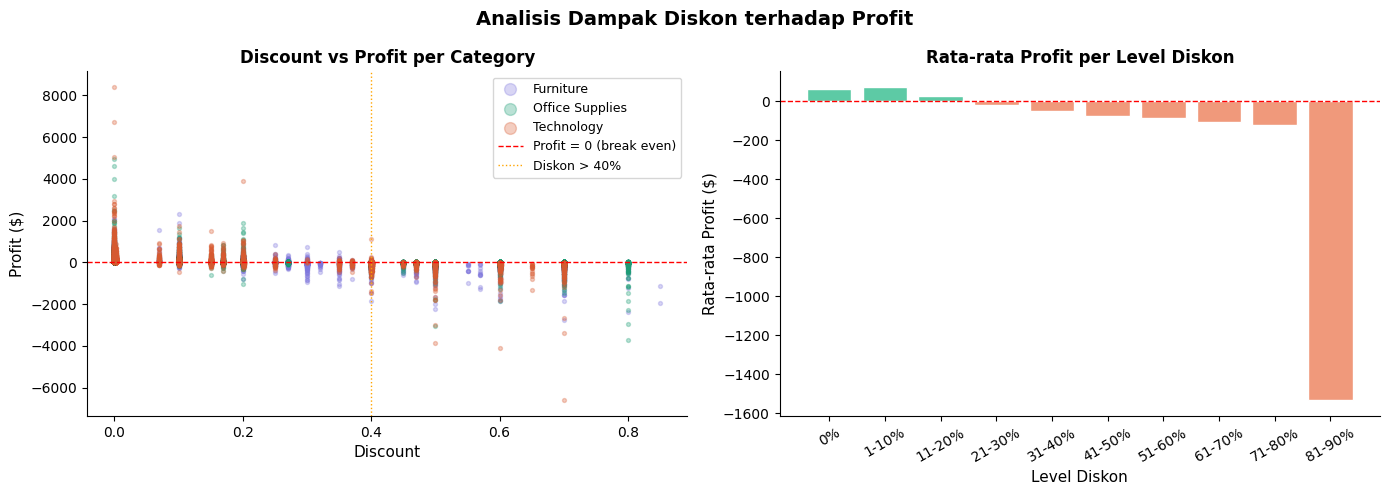

scatter discount vs profit berhasil disimpan


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: scatter semua data, warna per Category
category_colors = {'Furniture': '#7F77DD', 'Office Supplies': '#1D9E75', 'Technology': '#D85A30'}
for cat, color in category_colors.items():
    mask = df['Category'] == cat
    axes[0].scatter(df[mask]['Discount'], df[mask]['Profit'],
                    alpha=0.3, s=8, color=color, label=cat)

axes[0].axhline(0, color='red', linewidth=1, linestyle='--', label='Profit = 0 (break even)')
axes[0].axvline(0.4, color='orange', linewidth=1, linestyle=':', label='Diskon > 40%')
axes[0].set_xlabel('Discount', fontsize=11)
axes[0].set_ylabel('Profit ($)', fontsize=11)
axes[0].set_title('Discount vs Profit per Category', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, markerscale=3)
axes[0].spines[['top','right']].set_visible(False)

# Kanan: rata-rata profit per level diskon (lebih mudah dibaca)
df['Discount_bin'] = pd.cut(df['Discount'],
                             bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                             labels=['0%','1-10%','11-20%','21-30%','31-40%','41-50%','51-60%','61-70%','71-80%','81-90%'])
avg_profit = df.groupby('Discount_bin', observed=True)['Profit'].mean()
colors_bar = ['#F0997B' if v < 0 else '#5DCAA5' for v in avg_profit.values]
axes[1].bar(avg_profit.index, avg_profit.values, color=colors_bar, edgecolor='white')
axes[1].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_xlabel('Level Diskon', fontsize=11)
axes[1].set_ylabel('Rata-rata Profit ($)', fontsize=11)
axes[1].set_title('Rata-rata Profit per Level Diskon', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Analisis Dampak Diskon terhadap Profit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("scatter discount vs profit berhasil disimpan")

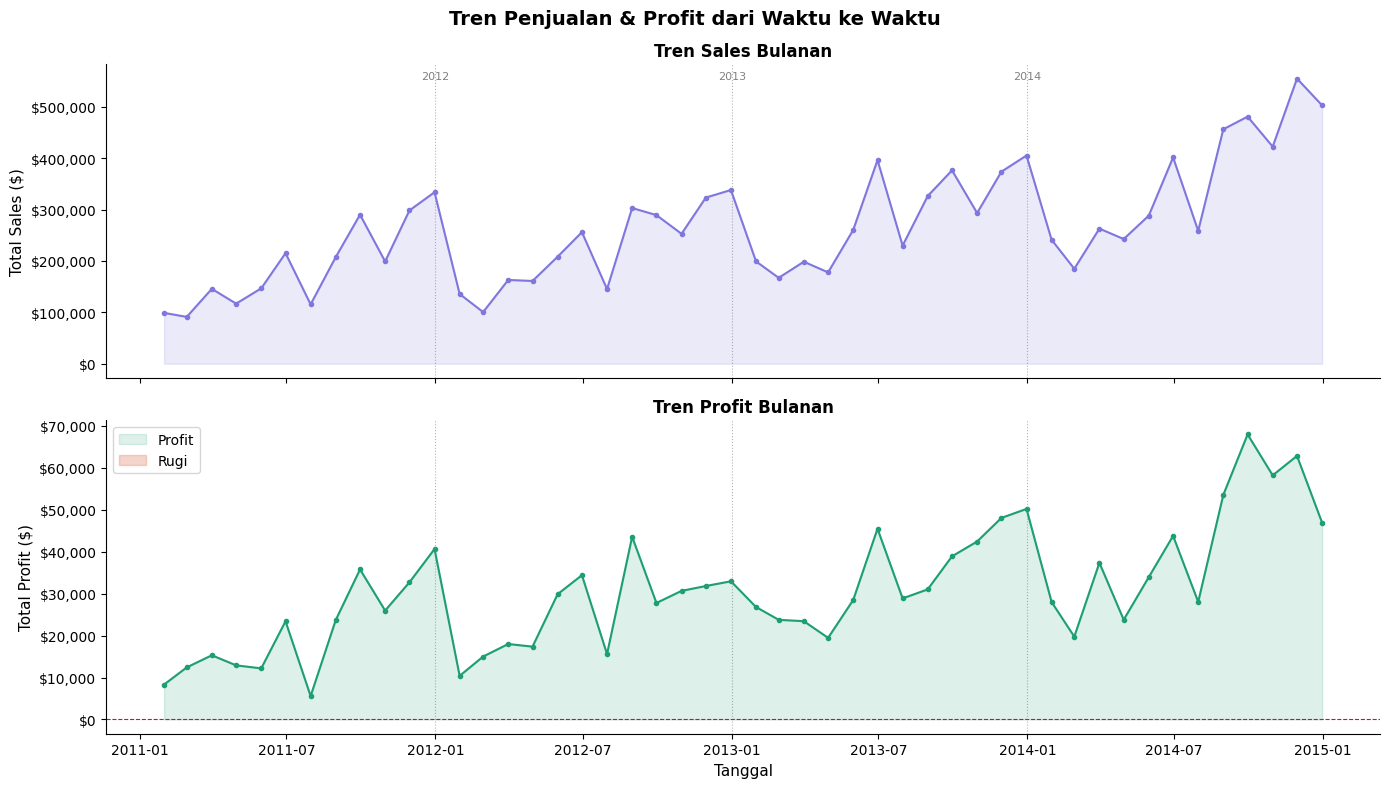

line chart tren waktu Done


In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True) 

df_time = df.set_index('Order Date')
monthly = df_time.resample('ME')[['Sales', 'Profit']].sum().reset_index()
monthly['Year'] = monthly['Order Date'].dt.year

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Sales bulanan
axes[0].plot(monthly['Order Date'], monthly['Sales'],
             color='#7F77DD', linewidth=1.5, marker='o', markersize=3)
axes[0].fill_between(monthly['Order Date'], monthly['Sales'],
                      alpha=0.15, color='#7F77DD')
axes[0].set_ylabel('Total Sales ($)', fontsize=11)
axes[0].set_title('Tren Sales Bulanan', fontsize=12, fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Profit bulanan
axes[1].plot(monthly['Order Date'], monthly['Profit'],
             color='#1D9E75', linewidth=1.5, marker='o', markersize=3)
axes[1].fill_between(monthly['Order Date'], monthly['Profit'],
                      where=(monthly['Profit'] >= 0), alpha=0.15, color='#1D9E75', label='Profit')
axes[1].fill_between(monthly['Order Date'], monthly['Profit'],
                      where=(monthly['Profit'] < 0),  alpha=0.25, color='#D85A30', label='Rugi')
axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Total Profit ($)', fontsize=11)
axes[1].set_xlabel('Tanggal', fontsize=11)
axes[1].set_title('Tren Profit Bulanan', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines[['top','right']].set_visible(False)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Garis untuk memisahkan tahun
for year in monthly['Year'].unique()[1:]:
    jan = pd.Timestamp(f'{year}-01-01')
    axes[0].axvline(jan, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    axes[1].axvline(jan, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    axes[0].text(jan, axes[0].get_ylim()[1]*0.95, str(year), fontsize=8, color='gray', ha='center')

plt.suptitle('Tren Penjualan & Profit dari Waktu ke Waktu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tren_waktu.png', dpi=150, bbox_inches='tight')
plt.show()
print("line chart tren waktu Done")



RFM preview — 1,590 unique customers
       Recency  Frequency  Monetary
count   1590.0     1590.0    1590.0
mean      85.4       16.2    7951.3
std      127.7       10.6    6936.6
min        1.0        1.0       7.2
25%       15.0        6.0    1674.8
50%       36.0       14.0    6248.1
75%      100.0       26.0   13133.1
max     1207.0       41.0   35668.1


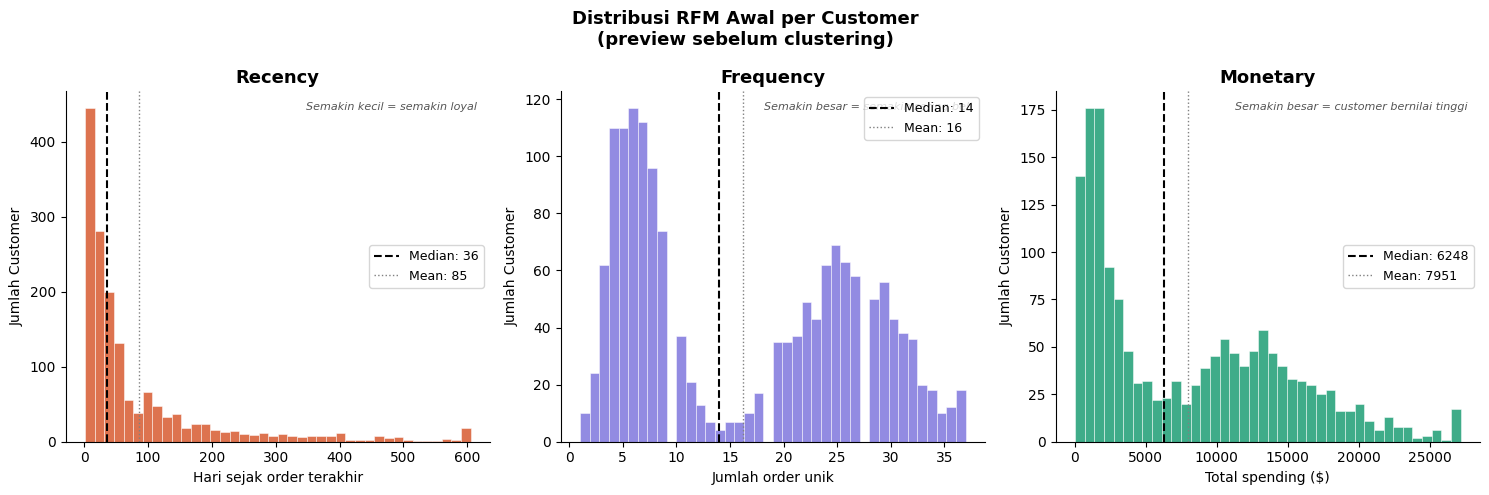

In [14]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Order ID',   'nunique'),
    Monetary  = ('Sales',      'sum')
).reset_index()

print(f"\nRFM preview — {len(rfm):,} unique customers")
print(rfm.describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
rfm_metrics = {
    'Recency':   ('Hari sejak order terakhir', '#D85A30', 'Semakin kecil = semakin loyal'),
    'Frequency': ('Jumlah order unik',          '#7F77DD', 'Semakin besar = semakin sering beli'),
    'Monetary':  ('Total spending ($)',          '#1D9E75', 'Semakin besar = customer bernilai tinggi'),
}

for i, (col, (xlabel, color, note)) in enumerate(rfm_metrics.items()):
    data = rfm[col]
    # Cap outlier untuk visualisasi (pakai 99th percentile)
    cap = data.quantile(0.99)
    data_capped = data.clip(upper=cap)

    axes[i].hist(data_capped, bins=40, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    axes[i].axvline(data.median(), color='black', linewidth=1.5, linestyle='--',
                    label=f'Median: {data.median():.0f}')
    axes[i].axvline(data.mean(),   color='gray',  linewidth=1,   linestyle=':',
                    label=f'Mean: {data.mean():.0f}')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel(xlabel, fontsize=10)
    axes[i].set_ylabel('Jumlah Customer', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].spines[['top','right']].set_visible(False)
    axes[i].text(0.97, 0.97, note, transform=axes[i].transAxes,
                 fontsize=8, va='top', ha='right', color='#555', style='italic')

plt.suptitle('Distribusi RFM Awal per Customer\n(preview sebelum clustering)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_awal.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
ig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

#Top 15 Sub-Category by jumlah order
ax1 = fig.add_subplot(gs[0, 0])
top_subcat = df['Sub-Category'].value_counts().head(15).sort_values()
bars = ax1.barh(top_subcat.index, top_subcat.values, color='#AFA9EC', edgecolor='white')
ax1.set_title('Top 15 Sub-Category\n(by jumlah order)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Jumlah Order', fontsize=9)
ax1.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, top_subcat.values):
    ax1.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8)

#Top 15 Sub-Category by total Sales
ax2 = fig.add_subplot(gs[0, 1])
top_sales = df.groupby('Sub-Category')['Sales'].sum().nlargest(15).sort_values()
bars2 = ax2.barh(top_sales.index, top_sales.values, color='#5DCAA5', edgecolor='white')
ax2.set_title('Top 15 Sub-Category\n(by total Sales)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Total Sales ($)', fontsize=9)
ax2.spines[['top','right']].set_visible(False)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

#Profit per Sub-Category (merah = rugi, hijau = untung)
ax3 = fig.add_subplot(gs[1, :])
profit_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors3 = ['#F0997B' if v < 0 else '#5DCAA5' for v in profit_subcat.values]
bars3 = ax3.barh(profit_subcat.index, profit_subcat.values, color=colors3, edgecolor='white')
ax3.axvline(0, color='red', linewidth=1, linestyle='--')
ax3.set_title('Total Profit per Sub-Category\n(merah = rugi — perlu diperhatikan untuk strategi bundling)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Total Profit ($)', fontsize=9)
ax3.spines[['top','right']].set_visible(False)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Analisis Produk — Persiapan Market Basket Analysis', fontsize=13, fontweight='bold')
plt.savefig('top_produk.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓selesai: top produk & sub-kategori")

<Figure size 1600x1000 with 0 Axes>

✓selesai: top produk & sub-kategori


In [19]:
# Preprocesing + Data Cleaning
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)
print("✓ Order Date & Ship Date → datetime")
# Drop kolom yang tidak digunakan
cols_to_drop = [
    'Row ID',
    'Postal Code',
    'Ship Date',
]
df.drop(columns=cols_to_drop, inplace=True)
print(f"Drop Kolom : {cols_to_drop} Berhasil...")

✓ Order Date & Ship Date → datetime
Drop Kolom : ['Row ID', 'Postal Code', 'Ship Date'] Berhasil...


In [20]:
# Check Missing Value
missing = df.isnull().sum()
missing = missing[missing>0]
if len(missing) == 0:
    print("Tidak ada missing value tersisa")
else:
    print(f"Missing Value:\n{missing}")

Tidak ada missing value tersisa


In [22]:
# Check Data Duplikat
n_dup = df.duplicated().sum()
print(f"Data Duplikat diemukkan : {n_dup}")

Data Duplikat diemukkan : 0


In [23]:
# Menambahkan fitur turunan dari tanggal (untuk tren)
df['Order_Year']  = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Quarter'] = df['Order Date'].dt.quarter
print("Berhasil Tambah kolom: Order_Year, Order_Month, Order_Quarter")

print(f"\nShape setelah basic cleaning: {df.shape}")

Berhasil Tambah kolom: Order_Year, Order_Month, Order_Quarter

Shape setelah basic cleaning: (51290, 25)


In [24]:
"""
RFM = metode segmentasi klasik:
  R (Recency)   = berapa hari sejak order terakhir
                  → kecil = baru beli = lebih loyal
  F (Frequency) = berapa banyak order unik
                  → besar = sering beli
  M (Monetary)  = total nilai Sales yang dihabiskan
                  → besar = customer bernilai tinggi
"""
napshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Customer_Name = ('Customer Name', 'first'),
    Segment       = ('Segment',       'first'),
    Recency       = ('Order Date',    lambda x: (snapshot_date - x.max()).days),
    Frequency     = ('Order ID',      'nunique'),
    Monetary      = ('Sales',         'sum'),
).reset_index()

print(f"RFM dibuat: {rfm.shape[0]} unique customers")
print(f"\nStatistik RFM:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(1))

RFM dibuat: 1590 unique customers

Statistik RFM:
       Recency  Frequency  Monetary
count   1590.0     1590.0    1590.0
mean      85.4       16.2    7951.3
std      127.7       10.6    6936.6
min        1.0        1.0       7.2
25%       15.0        6.0    1674.8
50%       36.0       14.0    6248.1
75%      100.0       26.0   13133.1
max     1207.0       41.0   35668.1


In [26]:
# Log transform (log1p = log(x+1)
# untuk mengecilkan jarak anatara nilai ekstrem
rfm['Recency_log']   = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log']  = np.log1p(rfm['Monetary'])

print("Log transform diterapkan: Recency, Frequency, Monetary")
print("  → Kolom baru: Recency_log, Frequency_log, Monetary_log")

Log transform diterapkan: Recency, Frequency, Monetary
  → Kolom baru: Recency_log, Frequency_log, Monetary_log


In [28]:
scaler = StandardScaler()
features_to_scale = ['Recency_log', 'Frequency_log', 'Monetary_log']

rfm_scaled = rfm.copy()
rfm_scaled[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']] = \
    scaler.fit_transform(rfm[features_to_scale])

print("StandardScaler diterapkan")
print("  → Kolom baru: Recency_scaled, Frequency_scaled, Monetary_scaled")
print(f"\nCek hasil scaling (harus mean≈0, std≈1):")
print(rfm_scaled[['Recency_scaled','Frequency_scaled','Monetary_scaled']].describe().round(3))


StandardScaler diterapkan
  → Kolom baru: Recency_scaled, Frequency_scaled, Monetary_scaled

Cek hasil scaling (harus mean≈0, std≈1):
       Recency_scaled  Frequency_scaled  Monetary_scaled
count        1590.000          1590.000         1590.000
mean            0.000             0.000            0.000
std             1.000             1.000            1.000
min            -2.198            -2.596           -4.876
25%            -0.644            -0.895           -0.747
50%            -0.018             0.140            0.274
75%             0.732             0.938            0.850
max             2.586             1.538            1.625


In [29]:
# Gunakan Sub-Category (bukan Product Name yang terlalu granular)
# Sub-Category punya 17 nilai unik — cukup untuk menemukan asosiasi bermakna
basket = df.groupby('Order ID')['Sub-Category'].apply(list).reset_index()
basket.columns = ['Order ID', 'Products']

# Statistik basket
basket['n_items'] = basket['Products'].apply(len)

print(f"✓ Basket dibuat: {len(basket):,} transaksi unik")
print(f"\nStatistik jumlah item per transaksi:")
print(basket['n_items'].describe().round(1))

# Filter: transaksi dengan minimal 2 item (single-item tidak berguna untuk basket analysis)
basket_filtered = basket[basket['n_items'] >= 2].copy()
print(f"\n✓ Filter transaksi ≥ 2 item: {len(basket_filtered):,} transaksi tersisa")
print(f"  ({len(basket) - len(basket_filtered):,} transaksi single-item dibuang)")

# Cek frekuensi tiap sub-kategori (support awal)
from collections import Counter
all_items = [item for sublist in basket_filtered['Products'] for item in sublist]
item_freq = pd.Series(Counter(all_items)).sort_values(ascending=False)
print(f"\nTop 10 Sub-Category paling sering muncul di basket:")
print(item_freq.head(10).to_string())


✓ Basket dibuat: 25,035 transaksi unik

Statistik jumlah item per transaksi:
count    25035.0
mean         2.0
std          1.5
min          1.0
25%          1.0
50%          2.0
75%          3.0
max         14.0
Name: n_items, dtype: float64

✓ Filter transaksi ≥ 2 item: 12,778 transaksi tersisa
  (12,257 transaksi single-item dibuang)

Top 10 Sub-Category paling sering muncul di basket:
Binders        4734
Storage        3824
Art            3682
Paper          2683
Chairs         2555
Phones         2553
Furnishings    2395
Accessories    2382
Labels         1961
Supplies       1879


In [ ]:
# File 1: RFM lengkap (clustering)
rfm_scaled.to_csv('df_customer_rfm_clean.csv', index=False)
print(f"✓ df_customer_rfm_clean.csv → {rfm_scaled.shape[0]:,} customers, {rfm_scaled.shape[1]} kolom")

# File 2: Basket (market basket)
basket_filtered.to_csv('df_basket.csv', index=False)
print(f"✓ df_basket.csv → {len(basket_filtered):,} transaksi siap Apriori")

# File 3: df bersih (untuk backend/database)
df.to_csv('df_clean.csv', index=False)
print(f"✓ df_clean.csv → {df.shape[0]:,} baris, {df.shape[1]} kolom (untuk Romi)")

print("\n✅ PREPROCESSING SELESAI")
print("=" * 55)
print("RINGKASAN KOLOM di df_customer_rfm_clean.csv:")
print("""
  IDENTITAS:
    Customer ID    → ID unik customer
    Customer Name  → nama customer
    Segment        → Consumer / Corporate / Home Office

  RFM ORIGINAL (nilai asli, untuk interpretasi):
    Recency        → hari sejak order terakhir
    Frequency      → jumlah order unik
    Monetary       → total spending ($)

  RFM LOG-TRANSFORMED (sudah dikurangi skewness):
    Recency_log    → log(Recency + 1)
    Frequency_log  → log(Frequency + 1)
    Monetary_log   → log(Monetary + 1)

  RFM SCALED (siap masuk K-Means):
    Recency_scaled   → mean=0, std=1
    Frequency_scaled → mean=0, std=1
    Monetary_scaled  → mean=0, std=1
""")
print("KOLOM INPUT K-MEANS yang dipakai:")
print("  → ['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']")
print("\nKOLOM INPUT APRIORI yang dipakai :")
print("  → kolom 'Products' di df_basket.csv (list of Sub-Category per Order)")


✓ df_customer_rfm_clean.csv → 1,590 customers, 12 kolom
✓ df_basket.csv → 12,778 transaksi siap Apriori
✓ df_clean.csv → 51,290 baris, 25 kolom (untuk Romi)

✅ PREPROCESSING SELESAI
RINGKASAN KOLOM di df_customer_rfm_clean.csv:

  IDENTITAS:
    Customer ID    → ID unik customer
    Customer Name  → nama customer
    Segment        → Consumer / Corporate / Home Office

  RFM ORIGINAL (nilai asli, untuk interpretasi):
    Recency        → hari sejak order terakhir
    Frequency      → jumlah order unik
    Monetary       → total spending ($)

  RFM LOG-TRANSFORMED (sudah dikurangi skewness):
    Recency_log    → log(Recency + 1)
    Frequency_log  → log(Frequency + 1)
    Monetary_log   → log(Monetary + 1)

  RFM SCALED (siap masuk K-Means):
    Recency_scaled   → mean=0, std=1
    Frequency_scaled → mean=0, std=1
    Monetary_scaled  → mean=0, std=1

KOLOM INPUT K-MEANS yang dipakai:
  → ['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']

KOLOM INPUT APRIORI yang dipakai :
  → k